In [1]:
import pandas as pd

df = pd.read_csv('/content/Preprocess_Weather_data.csv')
df.sample(10)

,Timestamp,PM2.5,PM10,Carbon_Monoxide_CO,Nitrogen_Dioxide_NO2,Sulphur_Dioxide_SO2,Ozone_O3,European_AQI,Temperature,Humidity,Wind_Speed,Air_Pressure,Rainfall,PM2.5_3h_Mean,PM2.5_3h_Std,PM2.5_6h_Mean,PM2.5_6h_Std,PM2.5_24h_Mean,PM2.5_24h_Std
19201,2025-03-12 00:00:00,31.8,35.7,378.0,27.6,5.2,64.0,70,14.2,89,3.4,1012.8,0.4,27.266667,4.051337,34.916667,13.330179,38.583333,25.125799
2669,2023-04-23 04:00:00,20.6,30.3,832.0,32.1,10.7,57.0,60,24.4,40,5.6,1009.5,0.0,23.266667,2.413158,24.066667,1.929421,25.087500,8.766503
15397,2024-10-04 12:00:00,35.7,59.4,774.0,46.1,9.4,81.0,72,28.8,71,3.9,1004.7,0.0,37.666667,1.738774,39.100000,1.929767,39.812500,5.541175
14012,2024-08-07 19:00:00,36.0,50.9,603.0,35.4,7.1,45.0,66,24.7,97,11.8,1003.6,0.4,36.600000,0.519615,35.133333,2.279181,32.625000,5.326901
4210,2023-06-26 09:00:00,19.6,30.0,266.0,6.1,7.0,145.0,72,31.1,58,10.8,1002.1,0.0,19.933333,0.288675,19.100000,1.100909,39.354167,17.840671
2090,2023-03-30 01:00:00,50.3,72.4,1506.0,49.7,10.5,17.0,75,14.3,76,7.1,1012.6,0.0,47.866667,2.804164,48.250000,1.845806,44.375000,6.030448
29626,2026-05-20 09:00:00,20.1,49.5,307.0,3.4,6.9,157.0,65,39.8,10,13.3,999.9,0.0,19.233333,0.776745,20.200000,1.931839,24.529167,7.985393
18363,2025-02-05 02:00:00,60.5,62.2,2092.0,49.2,9.6,26.0,88,8.0,65,3.4,1016.2,0.0,62.700000,3.810512,73.200000,12.747235,59.020833,24.935516
5103,2023-08-02 14:00:00,43.5,73.8,662.0,40.2,10.9,98.0,75,30.1,75,9.7,997.3,0.0,41.133333,2.454248,42.533333,2.605123,43.458333,5.506432
25464,2025-11-27 23:00:00,49.9,51.6,569.0,53.4,4.1,4.0,94,8.7,71,3.1,1020.0,0.0,58.233333,8.452416,72.850000,18.187441,67.345833,21.048205


In [2]:
!pip install lightgbm xgboost catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 7.9 MB/s eta 0:00:00


In [3]:
df["AQI_12h_Forecast"] = df["European_AQI"].shift(-12)

In [4]:
df.dropna(inplace=True)

In [5]:
X = df.drop(columns=[
    'Timestamp', 'AQI_3h_Forecast', 'Month', 'Day_Type', 'Hour', 'European_AQI', 'AQI_6h_Forecast', 'AQI_12h_Forecast', 'AQI_24h_Forecast', 'AQI_48h_Forecast'
], errors='ignore')

y = df['AQI_12h_Forecast']

In [6]:
X.columns

Index(['PM2.5', 'PM10', 'Carbon_Monoxide_CO', 'Nitrogen_Dioxide_NO2',
       'Sulphur_Dioxide_SO2', 'Ozone_O3', 'Temperature', 'Humidity',
       'Wind_Speed', 'Air_Pressure', 'Rainfall', 'PM2.5_3h_Mean',
       'PM2.5_3h_Std', 'PM2.5_6h_Mean', 'PM2.5_6h_Std', 'PM2.5_24h_Mean',
       'PM2.5_24h_Std'],
      dtype='object')

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostRegressor
import pandas as pd
import numpy as np
import joblib

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

models = {
    "XGBoost": xgb.XGBRegressor(n_estimators=100, learning_rate=0.05, random_state=42, n_jobs=-1),
    "LightGBM": lgb.LGBMRegressor(n_estimators=100, learning_rate=0.05, random_state=42, n_jobs=-1),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    "CatBoost": CatBoostRegressor(n_estimators=100, learning_rate=0.05, random_state=42, verbose=0)
}

forecasting_results = []
trained_models = {}

for name, model in models.items():
    print(f"Training {name} for 12-Hour Forecasting...")
    model.fit(X_train, y_train)
    trained_models[name] = model

    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    forecasting_results.append({
        "Model": name,
        "MAE": round(mae, 2),
        "RMSE": round(rmse, 2),
        "R2 Score (%)": round(r2 * 100, 2)
    })

results_df = pd.DataFrame(forecasting_results).sort_values(by="R2 Score (%)", ascending=False)
print("\nFinal 12-Hour Forecasting Model Comparison Matrix.")
print("="*60)
print(results_df.to_string(index=False))

Training XGBoost for 12-Hour Forecasting...
Training LightGBM for 12-Hour Forecasting...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.053806 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3984
[LightGBM] [Info] Number of data points in the train set: 24317, number of used features: 17
[LightGBM] [Info] Start training from score 69.283135
Training Random Forest for 12-Hour Forecasting...
Training CatBoost for 12-Hour Forecasting...

Final 12-Hour Forecasting Model Comparison Matrix.
        Model  MAE  RMSE  R2 Score (%)
Random Forest 2.98  4.31         91.34
      XGBoost 3.59  5.01         88.28
     LightGBM 3.67  5.09         87.89
     CatBoost 4.04  5.64         85.18


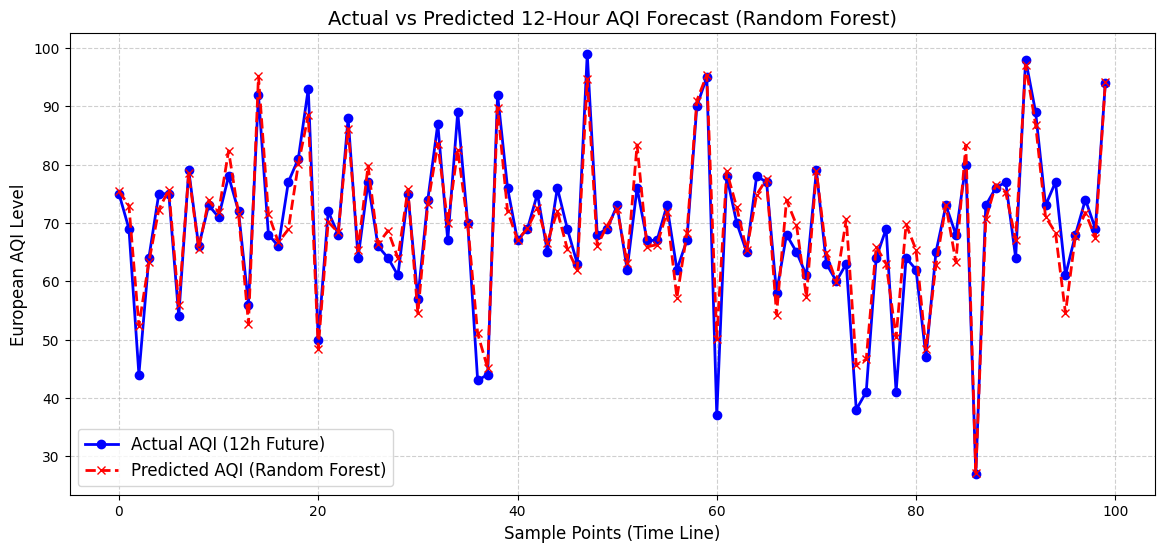

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

best_model_name = results_df.iloc[0]['Model']
best_model = trained_models[best_model_name]
y_pred_final = best_model.predict(X_test)

plt.figure(figsize=(14, 6))

plt.plot(y_test.values[:100], label='Actual AQI (12h Future)', color='blue', linewidth=2, marker='o')
plt.plot(y_pred_final[:100], label=f'Predicted AQI ({best_model_name})', color='red', linestyle='--', linewidth=2, marker='x')

plt.title(f"Actual vs Predicted 12-Hour AQI Forecast ({best_model_name})", fontsize=14)
plt.xlabel("Sample Points (Time Line)", fontsize=12)
plt.ylabel("European AQI Level", fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

In [11]:
import joblib
import os

os.makedirs("models", exist_ok=True)

rf_forecaster = trained_models["Random Forest"]
model_save_path = "models/random_forest_12hrsaqi_forecaster.pkl"

joblib.dump(rf_forecaster, model_save_path)

print(f"Model has been saved successfully {model_save_path}")

Model has been saved successfully models/random_forest_12hrsaqi_forecaster.pkl
